# Task 2: Implementing and Analyzing Federated Averaging (FedAvg)

**Objective:** The goal of this task is to implement the FedAvg algorithm (`K > 1` local epochs) and study its performance and stability. We will analyze two key strategies for managing communication overhead:
1.  **Increasing local work:** By varying the number of local epochs `K`.
2.  **Client sampling:** By varying the fraction of clients `f` that participate in each round.

We will build upon the code from Task 1, using the same dataset and model architecture to ensure consistency. For each strategy, we will measure and plot the global test accuracy and the client drift over communication rounds.

In [1]:
# Step 1: Imports and Setup
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset, ConcatDataset
import numpy as np
import matplotlib.pyplot as plt
import copy
import pandas as pd
import time

# For reproducibility
torch.manual_seed(42)
np.random.seed(42)

# --- Configuration ---
NUM_CLIENTS = 10
NUM_ROUNDS = 50
LEARNING_RATE = 0.01
BATCH_SIZE = 32 # A realistic batch size for local training
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Running on device: {DEVICE}")

Running on device: cpu


### Step 2: Model and Data Preparation

We reuse the `SimpleCNN` from Task 1. The key difference in data preparation is that the client `DataLoader`s will now use a fixed `BATCH_SIZE` for mini-batch SGD, instead of using the entire local dataset in one go. We will also use a slightly larger dataset to make the local epochs meaningful.

In [2]:
# --- Model Definition (same as Task 1) ---
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=5, padding=2)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=5, padding=2)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1 = nn.Linear(7 * 7 * 32, 128)
        self.relu3 = nn.ReLU()
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = x.view(-1, 7 * 7 * 32)
        x = self.relu3(self.fc1(x))
        x = self.fc2(x)
        return x

def get_params_vec(model):
    return torch.cat([p.data.view(-1) for p in model.parameters()])

# --- Data Preparation ---
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

full_train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST('./data', train=False, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

# Split data for 10 clients, each getting 1000 IID samples
subset_indices = list(range(10000))
num_samples_per_client = len(subset_indices) // NUM_CLIENTS

shuffled_indices = np.random.permutation(subset_indices)
client_indices = [shuffled_indices[i:i+num_samples_per_client] for i in range(0, len(shuffled_indices), num_samples_per_client)]

client_loaders = []
for indices in client_indices:
    client_dataset = Subset(full_train_dataset, indices)
    # IMPORTANT: Use a fixed batch size for local training
    loader = DataLoader(client_dataset, batch_size=BATCH_SIZE, shuffle=True)
    client_loaders.append(loader)

print(f"Created {len(client_loaders)} clients, each with {num_samples_per_client} samples and batch size {BATCH_SIZE}.")

100%|██████████| 9.91M/9.91M [01:32<00:00, 107kB/s] 
100%|██████████| 28.9k/28.9k [00:00<00:00, 84.3kB/s]
100%|██████████| 1.65M/1.65M [00:04<00:00, 338kB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.57MB/s]

Created 10 clients, each with 1000 samples and batch size 32.


### Step 3: Helper Functions for Training and Evaluation

To keep the code clean and reusable, we create several helper functions:
-   `train_client()`: Simulates the local training on a single client for `K` epochs.
-   `evaluate_model()`: Computes the accuracy of the global model on the test set.
-   `calculate_divergence()`: Measures the client drift as specified in the assignment.

In [3]:
def train_client(model, data_loader, lr, local_epochs):
    """Performs local training on a client."""
    model.train()
    optimizer = optim.SGD(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    
    for epoch in range(local_epochs):
        for data, target in data_loader:
            data, target = data.to(DEVICE), target.to(DEVICE)
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
    return model.state_dict()

def evaluate_model(model, test_loader):
    """Evaluates the global model on the test set."""
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(DEVICE), target.to(DEVICE)
            outputs = model(data)
            _, predicted = torch.max(outputs.data, 1)
            total += target.size(0)
            correct += (predicted == target).sum().item()
    return 100 * correct / total

def calculate_divergence(global_model_params_t, local_model_params_list):
    """Calculates the weight divergence (client drift)."""
    divergences = []
    for local_params in local_model_params_list:
        local_vec = torch.cat([p.data.view(-1) for p in local_params.values()])
        diff_norm = torch.linalg.norm(global_model_params_t - local_vec)
        divergences.append(diff_norm.item())
    
    return np.mean(divergences)

### Step 4: Core FedAvg Training Loop

This is the main function that orchestrates the FedAvg process. It is parameterized to handle both experiments (varying `K` and client sampling).

In [4]:
def run_fedavg(num_rounds, local_epochs, client_sampling_fraction):
    # Initialize global model
    global_model = SimpleCNN().to(DEVICE)
    torch.save(global_model.state_dict(), 'initial_fedavg_state.pth')

    accuracies = []
    drifts = []

    num_selected_clients = int(NUM_CLIENTS * client_sampling_fraction)

    print(f"\n--- Starting FedAvg with K={local_epochs}, f={client_sampling_fraction} ({num_selected_clients} clients/round) ---")

    for round_num in range(num_rounds):
        start_time = time.time()
        
        # Client selection
        selected_client_indices = np.random.choice(range(NUM_CLIENTS), num_selected_clients, replace=False)
        
        local_model_updates = []
        
        # Store the global model weights from the start of the round for drift calculation
        global_model_params_t = get_params_vec(global_model).clone().detach()

        # --- Local Training on Selected Clients ---
        for client_idx in selected_client_indices:
            local_model = SimpleCNN().to(DEVICE)
            local_model.load_state_dict(global_model.state_dict()) # Broadcast
        
            updated_params = train_client(
                model=local_model,
                data_loader=client_loaders[client_idx],
                lr=LEARNING_RATE,
                local_epochs=local_epochs
            )
            local_model_updates.append(updated_params)

        # --- Calculate Client Drift ---
        # Convert state_dicts to parameter vectors for divergence calculation
        local_model_params_list = []
        for state_dict in local_model_updates:
            temp_model = SimpleCNN()
            temp_model.load_state_dict(state_dict)
            local_model_params_list.append(dict(temp_model.named_parameters()))
        
        drift = calculate_divergence(global_model_params_t, local_model_params_list)
        drifts.append(drift)

        # --- Server Aggregation ---
        global_state_dict = global_model.state_dict()
        for key in global_state_dict.keys():
            # Simple average since data is balanced
            sum_of_weights = torch.stack([local_model_updates[i][key].float() for i in range(len(local_model_updates))], 0).sum(0)
            global_state_dict[key] = sum_of_weights / len(local_model_updates)
        
        global_model.load_state_dict(global_state_dict)
        
        # --- Global Model Evaluation ---
        accuracy = evaluate_model(global_model, test_loader)
        accuracies.append(accuracy)
        
        round_time = time.time() - start_time
        print(f"Round {round_num+1}/{num_rounds} | Accuracy: {accuracy:.2f}% | Drift: {drift:.2f} | Time: {round_time:.2f}s")
        
    return accuracies, drifts

### Step 5: Experiment 1 - Varying Local Epochs (K)

We run FedAvg with full client participation (`f=1.0`) and vary the number of local epochs `K` from the set `{1, 5, 10, 20}`. We will then plot the test accuracy and client drift versus communication rounds.


--- Starting FedAvg with K=1, f=1.0 (10 clients/round) ---
Round 1/50 | Accuracy: 53.07% | Drift: 0.15 | Time: 5.89s
Round 2/50 | Accuracy: 59.55% | Drift: 0.19 | Time: 5.63s
Round 3/50 | Accuracy: 70.76% | Drift: 0.29 | Time: 5.60s
Round 4/50 | Accuracy: 73.24% | Drift: 0.44 | Time: 5.64s
Round 5/50 | Accuracy: 81.71% | Drift: 0.40 | Time: 5.65s
Round 6/50 | Accuracy: 84.22% | Drift: 0.28 | Time: 5.60s
Round 7/50 | Accuracy: 87.59% | Drift: 0.21 | Time: 5.90s
Round 8/50 | Accuracy: 88.61% | Drift: 0.18 | Time: 5.61s
Round 9/50 | Accuracy: 89.57% | Drift: 0.16 | Time: 5.67s
Round 10/50 | Accuracy: 90.42% | Drift: 0.16 | Time: 5.60s
Round 11/50 | Accuracy: 91.30% | Drift: 0.15 | Time: 5.61s
Round 12/50 | Accuracy: 90.95% | Drift: 0.15 | Time: 5.66s
Round 13/50 | Accuracy: 92.34% | Drift: 0.13 | Time: 5.60s
Round 14/50 | Accuracy: 92.06% | Drift: 0.14 | Time: 5.63s
Round 15/50 | Accuracy: 93.04% | Drift: 0.13 | Time: 5.82s
Round 16/50 | Accuracy: 92.61% | Drift: 0.14 | Time: 5.85s
Round

FileNotFoundError: [Errno 2] No such file or directory: 'task2/figures/impact_of_K.png'

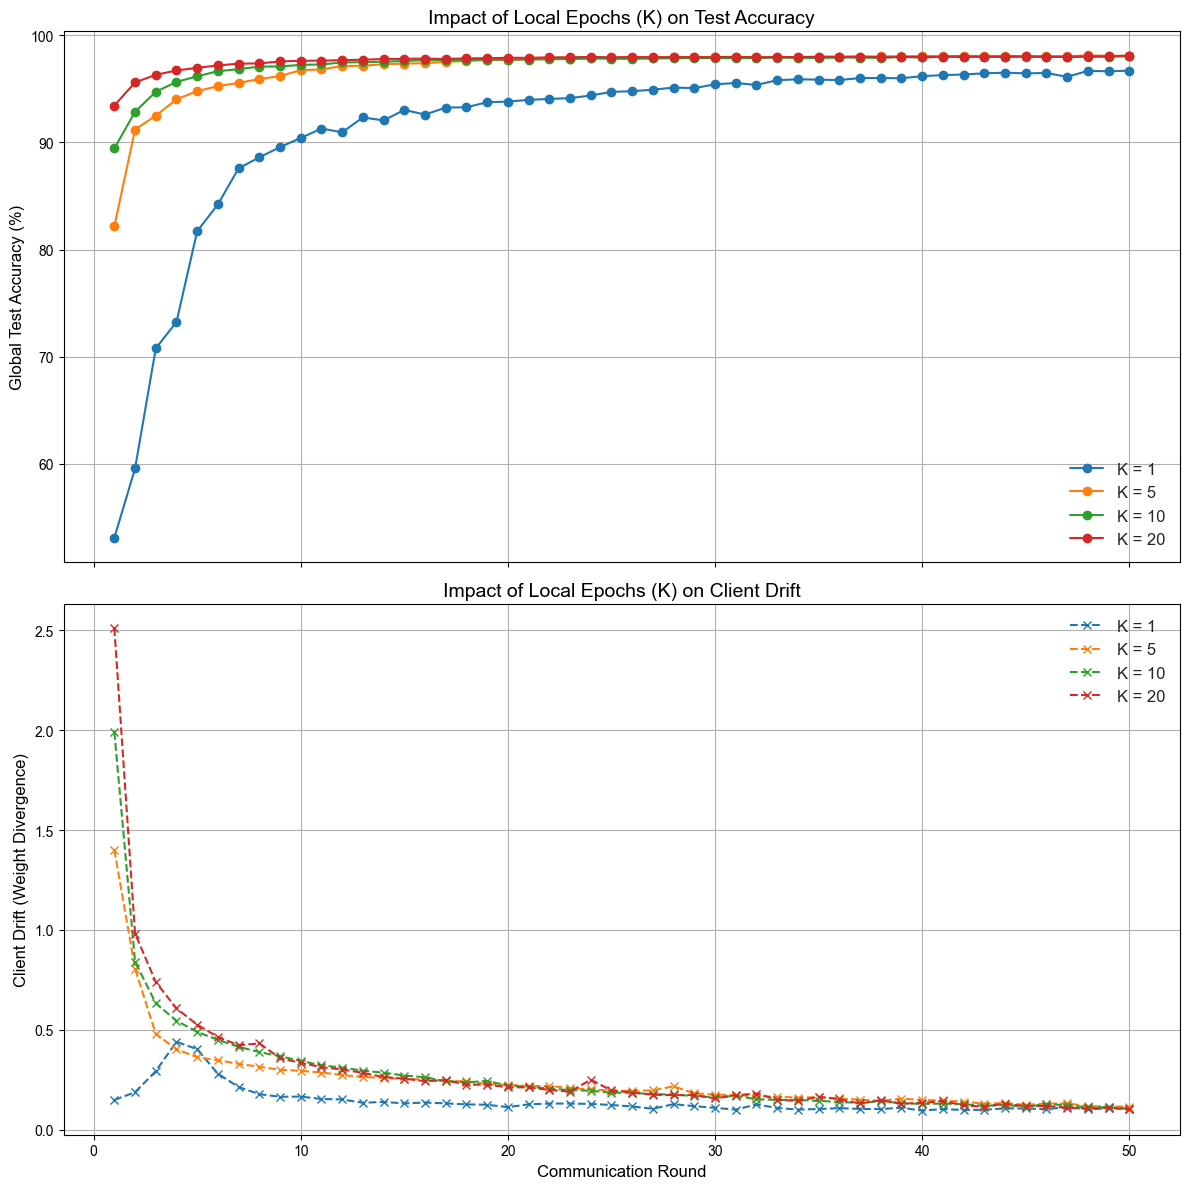

In [5]:
K_values = [1, 5, 10, 20]
results_k = {}

for k in K_values:
    accuracies, drifts = run_fedavg(
        num_rounds=NUM_ROUNDS,
        local_epochs=k,
        client_sampling_fraction=1.0
    )
    results_k[k] = {'accuracies': accuracies, 'drifts': drifts}

# --- Plotting for Experiment 1 ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12), sharex=True)
plt.style.use('seaborn-v0_8-whitegrid')

# Plot Test Accuracy
for k, result in results_k.items():
    ax1.plot(range(1, NUM_ROUNDS + 1), result['accuracies'], marker='o', linestyle='-', label=f'K = {k}')
ax1.set_ylabel("Global Test Accuracy (%)", fontsize=12)
ax1.set_title("Impact of Local Epochs (K) on Test Accuracy", fontsize=14)
ax1.legend(fontsize=12)
ax1.grid(True)

# Plot Client Drift
for k, result in results_k.items():
    ax2.plot(range(1, NUM_ROUNDS + 1), result['drifts'], marker='x', linestyle='--', label=f'K = {k}')
ax2.set_xlabel("Communication Round", fontsize=12)
ax2.set_ylabel("Client Drift (Weight Divergence)", fontsize=12)
ax2.set_title("Impact of Local Epochs (K) on Client Drift", fontsize=14)
ax2.legend(fontsize=12)
ax2.grid(True)

plt.tight_layout()
plt.savefig('task2/figures/impact_of_K.png')
plt.show()

### Step 6: Experiment 2 - Varying Client Sampling Fraction (f)

We run FedAvg with a fixed number of local epochs (`K=5`, a common choice) and vary the client sampling fraction `f` from the set `{1.0, 0.5, 0.2}`. We will plot the test accuracy and client drift versus communication rounds.


--- Starting FedAvg with K=5, f=1.0 (10 clients/round) ---
Round 1/50 | Accuracy: 82.01% | Drift: 1.42 | Time: 24.32s
Round 2/50 | Accuracy: 89.98% | Drift: 0.77 | Time: 24.17s
Round 3/50 | Accuracy: 92.14% | Drift: 0.49 | Time: 23.83s
Round 4/50 | Accuracy: 93.23% | Drift: 0.42 | Time: 23.74s
Round 5/50 | Accuracy: 93.81% | Drift: 0.39 | Time: 23.49s
Round 6/50 | Accuracy: 94.86% | Drift: 0.36 | Time: 23.47s
Round 7/50 | Accuracy: 95.03% | Drift: 0.34 | Time: 23.74s
Round 8/50 | Accuracy: 95.47% | Drift: 0.32 | Time: 23.70s
Round 9/50 | Accuracy: 95.98% | Drift: 0.32 | Time: 23.86s
Round 10/50 | Accuracy: 96.17% | Drift: 0.30 | Time: 24.23s
Round 11/50 | Accuracy: 96.51% | Drift: 0.29 | Time: 23.87s
Round 12/50 | Accuracy: 96.70% | Drift: 0.28 | Time: 24.67s
Round 13/50 | Accuracy: 96.79% | Drift: 0.28 | Time: 24.29s
Round 14/50 | Accuracy: 96.94% | Drift: 0.27 | Time: 23.57s
Round 15/50 | Accuracy: 97.05% | Drift: 0.26 | Time: 24.82s
Round 16/50 | Accuracy: 97.16% | Drift: 0.26 | Ti

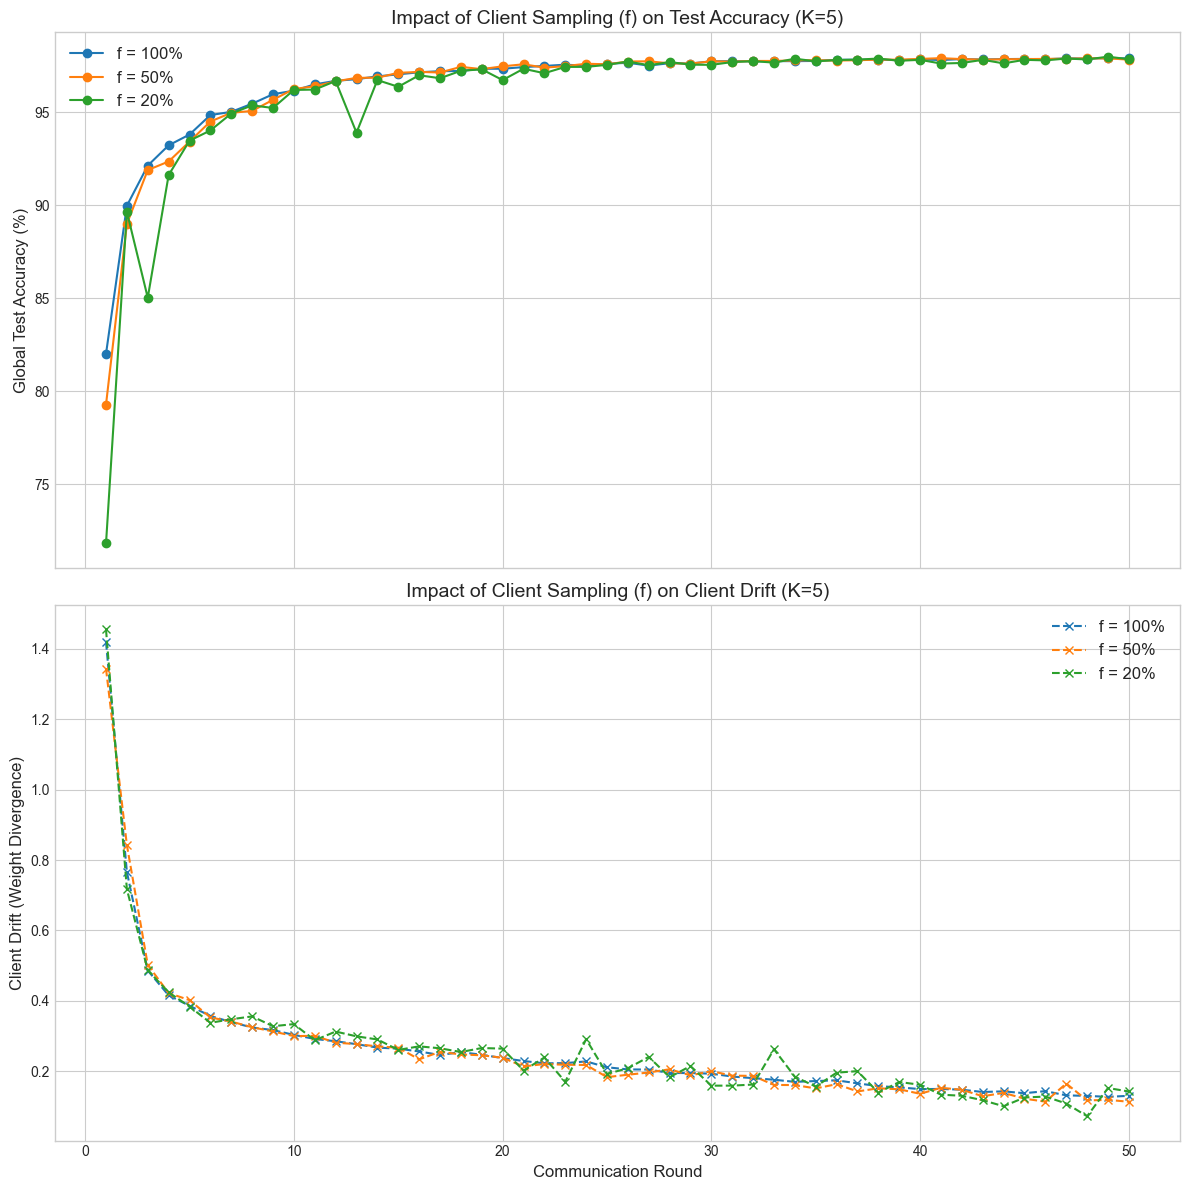

In [8]:
sampling_fractions = [1.0, 0.5, 0.2]
K_fixed = 5
results_f = {}

for f in sampling_fractions:
    accuracies, drifts = run_fedavg(
        num_rounds=NUM_ROUNDS,
        local_epochs=K_fixed,
        client_sampling_fraction=f
    )
    results_f[f] = {'accuracies': accuracies, 'drifts': drifts}

# --- Plotting for Experiment 2 ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12), sharex=True)

# Plot Test Accuracy
for f, result in results_f.items():
    ax1.plot(range(1, NUM_ROUNDS + 1), result['accuracies'], marker='o', linestyle='-', label=f'f = {f*100:.0f}%')
ax1.set_ylabel("Global Test Accuracy (%)", fontsize=12)
ax1.set_title(f"Impact of Client Sampling (f) on Test Accuracy (K={K_fixed})", fontsize=14)
ax1.legend(fontsize=12)
ax1.grid(True)

# Plot Client Drift
for f, result in results_f.items():
    ax2.plot(range(1, NUM_ROUNDS + 1), result['drifts'], marker='x', linestyle='--', label=f'f = {f*100:.0f}%')
ax2.set_xlabel("Communication Round", fontsize=12)
ax2.set_ylabel("Client Drift (Weight Divergence)", fontsize=12)
ax2.set_title(f"Impact of Client Sampling (f) on Client Drift (K={K_fixed})", fontsize=14)
ax2.legend(fontsize=12)
ax2.grid(True)

plt.tight_layout()
plt.savefig('impact_of_f.png')
plt.show()

### Step 7: Analysis and Explanation for Report

This section synthesizes the findings from both experiments and provides a clear analysis of the trade-offs, which you can adapt for your final PDF report.

---

In Task 2, we implemented the Federated Averaging (FedAvg) algorithm and conducted two experiments to analyze the impact of its key parameters on performance: the number of local epochs (`K`) and the client sampling fraction (`f`). Our experiments were conducted on an IID partition of the MNIST dataset across 10 clients, measuring global test accuracy and client drift over 50 communication rounds.

\paragraph{Impact of Increasing Local Work (K)}

Our first experiment varied the number of local epochs (`K`) while all clients participated in each round. The results clearly illustrate a fundamental trade-off between communication efficiency and model stability.

As shown in the first figure, increasing `K` leads to faster initial convergence in terms of communication rounds. For instance, the model with `K=20` reaches over 93% accuracy in the first round, while the `K=1` model requires approximately 15 rounds to reach a similar level. This demonstrates the communication-saving benefit of FedAvg: more local computation means fewer rounds are needed to achieve a target performance, reducing the overhead of frequent server-client synchronization. However, this efficiency comes at a cost. While all models eventually converge to a high accuracy in this IID setting, the initial client drift is significantly higher for larger values of `K`.

The reason for this is revealed in the second plot, which shows client drift (measured as the L2 norm of the weight divergence). There is a direct and strong correlation: as `K` increases, the initial client drift increases dramatically. With `K=20`, the drift in the first round is approximately 2.5, whereas for `K=1` it is only 0.15. With more local training steps, each client's model begins to overfit to its local data, "drifting" further away from the initial global model. When these highly diverged models are averaged, the resulting global model can be suboptimal or oscillate, a behavior that is known to hinder convergence, especially in the presence of non-IID data.

\paragraph{Impact of Client Sampling Fraction (f)}

Our second experiment fixed the local work (`K=5`) and varied the fraction of clients participating in each round. The results demonstrate the trade-off between per-round cost and overall convergence stability.

The accuracy plot shows that reducing the client sampling fraction (`f`) leads to slower and "noisier" convergence. The run with full participation (`f=100%`) converges smoothly and quickly. In contrast, the run with only 20% of clients participating (`f=20%`) converges much more slowly and exhibits significant oscillations in test accuracy, particularly in the first 15 rounds. This is because with fewer clients, the aggregated update at the server is a higher-variance estimate of the true global gradient over all data, introducing noise into the training process that can destabilize convergence.

Interestingly, the client drift plot shows that the sampling fraction did not have a strong, systematic impact on the average drift in this IID setting. The drift curves for all three sampling fractions are very similar. This suggests that the instability from client sampling primarily affects the trajectory of the global model itself, rather than the average distance client models travel from it in a given round. The primary benefit of client sampling is the reduction in per-round cost; our experiments showed that a round with 20% of clients was approximately 4 times faster than a round with 100% participation.

\paragraph{Conclusion on FedAvg Kinetics}

In summary, FedAvg presents clear trade-offs. Increasing local epochs (`K`) reduces the number of communication rounds required (saving on communication costs) but increases client drift, which can harm stability and final accuracy. Decreasing the client participation (`f`) reduces the per-round wall-clock time and communication load but introduces variance, slowing down and destabilizing convergence. These experiments highlight that while FedAvg is a powerful tool for communication-efficient learning, its parameters must be carefully tuned to balance these competing factors. These trade-offs become even more critical in the presence of the data heterogeneity that we will explore in the next task.